# 01211373 : Machine Learning and Programming for Industry

## Lecture 09 : Neural Networks and Deep Learning

**Topics :**

* Implementing an NN model from scratch
* Building an NN model in PyTorch

**Note :** Since there are abundant of deep learning contents you could find online, this notebook just contains selected code from chapter 11- 12 of [1] with minimal reading materials.

## 9.1 Implementing an NN model from scratch

### 9.1.1 Single-layer neural network 

Recall the ADAptive LInear NEuron (Adaline) algorithm in figure 9.1

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch11/figures/11_01.png" width=800 />

Figure 9.1  The Adaline algorithm (Figure 11.1 of [1])

Gradient descent optimization is used to learn the weight coefficient of the model. In every epoch, the weight vetor $w$ and bias $b$ is updated using the following update rules
$$
\begin{align*}
w &:= w + \Delta w \\
b &:= b + \Delta b \tag{9.1}
\end{align*}
$$
where
$$
\begin{align*}
\Delta w_j &= -\eta \frac{\partial L}{\partial w_j} \\
\Delta b_j &= -\eta \frac{\partial L}{\partial b}. \tag{9.2}
\end{align*}
$$
The loss function is the mean squared errors (MSE), and $\eta$ is the learning rate we have to choose carefully to balance the speed of learning against the risk of overshooting the global minimum of the loss function.

For the Adaline, 
$$
\frac{\partial L}{\partial w_j} = \frac{\partial}{\partial w_j}\frac{1}{n}\sum_i \left(y^{(i)}-a^{(i)}\right)^2 = 
-\frac{2}{n}\sum_i \left(y^{(i)}-a^{(i)}\right)x_j^{(i)} \tag{9.3}
$$

The activation function $\sigma(.)$ is defined as
$$
\sigma(.) = z = a \tag{9.4}
$$
The net input $z$ is a linear combination of the weights that connect the input layer to the output layer
$$
z = \sum_jw_jx_j + b = w^Tx + b \tag{9.5}
$$
Note that while the activation $\sigma(.)$ is used to compute the gradient uptate, the prediction is done by a threshold function that squashes the continouous-valued output into binary class labels
$$
\hat{y} = \begin{cases}
1 & \text{if} \;\;z \ge 0 \\
0 & \text{otherwise}
\end{cases} \tag{9.6}
$$

### 9.1.2 Introducing the multilayer neural network architecture

Figure 9.2 shows a typical structure of a multilayer feedforward NN. This fully-connected network is also called a Multi-Layer Perceptron (MLP) or Dense Neural Network (DNN). To conform to the discussion from [1], we will call it MLP.

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/L09_dnn.png" width=800 />

Figure 9.2  A multilayer neural network (MLP)

To illustrate the concept, we show a simple MLP consisting of two layers shown in Figure 9.3.

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch11/figures/11_02.png" width=800 />

Figure 9.3  A two-layer MLP (Figure 11.2 of [1])


### 9.1.3 Activating a neural network via forward propagation

In this section, we will describe the process of forward propagation to calculate the output of an MLP
model. To understand how it fits into the context of learning an MLP model, let’s summarize the MLP
learning procedure in three simple steps:

1. Starting at the input layer, we forward propagate the patterns of the training data through the
network to generate an output.

2. Based on the network’s output, we calculate the loss that we want to minimize using a loss
function that we will describe later.

3. We backpropagate the loss, find its derivative with respect to each weight and bias unit in the
network, and update the model.

This is summarized in Figure 9.3.

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/L09_dl_structure.jpg" width=700 />

Figure 9.3 MLP learning structure [3]

Finally, after we repeat these three steps for multiple epochs and learn the weight and bias parameters
of the MLP, we use forward propagation to calculate the network output and apply a threshold
function to obtain the predicted class labels. One-hot representation is normally used in multi-class classification.

The activation unit of the hidden layer $a_1^{(h)}$ can be calculated as follows:
$$
\begin{align*}
z_1^{(h)} &= x_1^{(in)}w_{1,1}^{(h)} + x_2^{(in)}w_{1,2}^{(h)}+ \ldots + x_m^{(in)}w_{1,m}^{(h)} + b_1^{(h)} \\
a_1^{(h)} &= \sigma(z_1^{(h)}) \tag{9.7}
\end{align*}
$$

Here we use superscript as layer number. So $z_1^{(h)}$ is the net input of hidden layer, and $\sigma(.)$ is the activation function. One can show that, in order for the hidden layer to be useful, the activation  must be a nonlinear function. Otherwise, the MLP could be collapsed to a single layer NN. 
For example, the sigmoid (logistic) activation function can be used.
$$
\sigma(z) = \frac{1}{1+e^{-z}} \tag{9.8}
$$


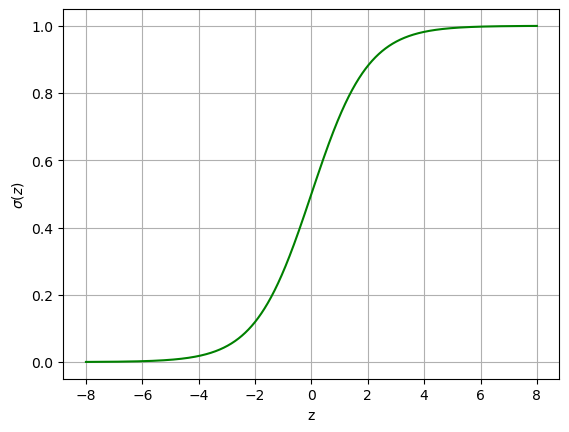

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1/(1+np.exp(-z))

z = np.arange(-8,8,0.001)
a = sigmoid(z)
plt.plot(z,a,'g-')
plt.xlabel('z')
plt.ylabel('$\\sigma(z)$')
plt.grid()
plt.show()

For all $n$ examples in the training dataset, we can write (9.7) in more compact form as
$$
\begin{align*}
Z^{(h)} &= X^{(in)}W^{(h)T} + b^{(h)} \\
A^{(h)} &= \sigma(Z^{(h)}) \tag{9.9}
\end{align*}
$$
And for the output layer
$$
\begin{align*}
Z^{(out)} &= A^{(h)}W^{(out)T} + b^{(out)} \\
A^{(out)} &= \sigma(Z^{(out)}) \tag{9.10}
\end{align*}
$$

### 9.1.4 Classifying handwritten digits

In this section, we will implement and train our first multilayer NN to classify handwritten digits
from the popular Mixed National Institute of Standards and Technology (MNIST) dataset that has
been constructed by Yann LeCun and others and serves as a popular benchmark dataset for machine
learning algorithms [4].

#### Obtaining and preparing the MNIST dataset

The MNIST dataset is publicly available at http://yann.lecun.com/exdb/mnist/ and consists of the following four parts:

- Training set images: train-images-idx3-ubyte.gz (9.9 MB, 47 MB unzipped, 60,000 examples)
- Training set labels: train-labels-idx1-ubyte.gz (29 KB, 60 KB unzipped, 60,000 labels)
- Test set images: t10k-images-idx3-ubyte.gz (1.6 MB, 7.8 MB, 10,000 examples)
- Test set labels: t10k-labels-idx1-ubyte.gz (5 KB, 10 KB unzipped, 10,000 labels)


In [2]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.values
y = y.astype(int).values

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


The images in the MNIST dataset consist of 28×28 pixels, and each pixel is represented by a grayscale
intensity value. Here, fetch_openml already unrolled the 28×28 pixels into one-dimensional row
vectors, which represent the rows in our X array (784 per row or image) above. The second array (y)
returned by the fetch_openml function contains the corresponding target variable, the class labels
(integers 0-9) of the handwritten digits.

let’s normalize the pixels values in MNIST to the range –1 to 1 (originally 0 to 255) via the following
code line. 

In [3]:
X = ((X / 255.) - .5) * 2

To get an idea of how those images in MNIST look, let’s visualize examples of the digits 0-9 after reshaping
the 784-pixel vectors from our feature matrix into the original 28×28 image that we can plot
via Matplotlib’s imshow function.

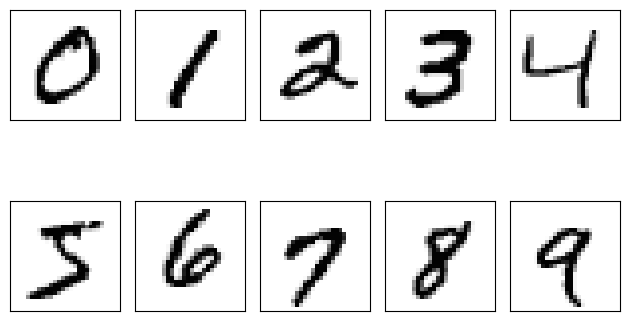

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In addition, let’s also plot multiple examples of the same digit to see how different the handwriting
for each really is. For example, to see the first 25 variants of the digit 7:

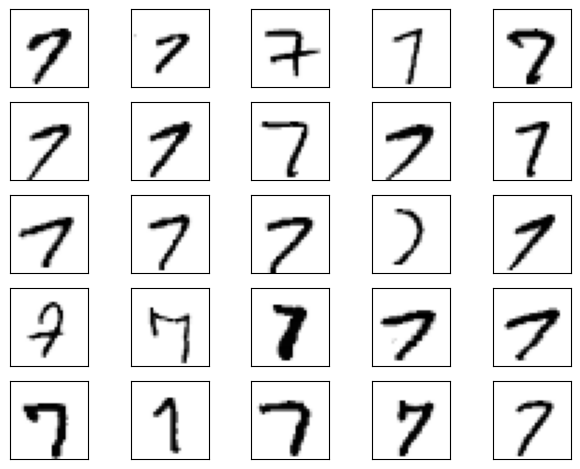

In [5]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(25):
    img = X[y == 7][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

Finally, let’s divide the dataset into training, validation, and test subsets. The following code will split
the dataset such that 55,000 images are used for training, 5,000 images for validation, and 10,000
images for testing. 

In [6]:
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=10000, random_state=123, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=5000, random_state=123, stratify=y_temp)

# optional to free up some memory by deleting non-used arrays:
del X_temp, y_temp, X, y

#### Implementing a multilayer perceptron

Let’s look at the following implementation of an MLP, starting with the two helper functions to
compute the logistic sigmoid activation and to convert integer class label arrays to one-hot encoded
labels. Then, we implement the main class for our MLP, which we call NeuralNetMLP, consiting 3 class methods: .\__init__() , .forward(), .backward(). See detailed explanation in [1].

In [7]:
def sigmoid(z):                                        
    return 1. / (1. + np.exp(-z))


def int_to_onehot(y, num_labels):

    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1

    return ary


class NeuralNetMLP:

    def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
        super().__init__()
        
        self.num_classes = num_classes
        
        # hidden
        rng = np.random.RandomState(random_seed)
        
        self.weight_h = rng.normal(
            loc=0.0, scale=0.1, size=(num_hidden, num_features))
        self.bias_h = np.zeros(num_hidden)
        
        # output
        self.weight_out = rng.normal(
            loc=0.0, scale=0.1, size=(num_classes, num_hidden))
        self.bias_out = np.zeros(num_classes)
        
    def forward(self, x):
        # Hidden layer
        # input dim: [n_examples, n_features] dot [n_hidden, n_features].T
        # output dim: [n_examples, n_hidden]
        z_h = np.dot(x, self.weight_h.T) + self.bias_h
        a_h = sigmoid(z_h)

        # Output layer
        # input dim: [n_examples, n_hidden] dot [n_classes, n_hidden].T
        # output dim: [n_examples, n_classes]
        z_out = np.dot(a_h, self.weight_out.T) + self.bias_out
        a_out = sigmoid(z_out)
        return a_h, a_out

    def backward(self, x, a_h, a_out, y):  
    
        #########################
        ### Output layer weights
        #########################
        
        # onehot encoding
        y_onehot = int_to_onehot(y, self.num_classes)

        # Part 1: dLoss/dOutWeights
        ## = dLoss/dOutAct * dOutAct/dOutNet * dOutNet/dOutWeight
        ## where DeltaOut = dLoss/dOutAct * dOutAct/dOutNet
        ## for convenient re-use
        
        # input/output dim: [n_examples, n_classes]
        d_loss__d_a_out = 2.*(a_out - y_onehot) / y.shape[0]

        # input/output dim: [n_examples, n_classes]
        d_a_out__d_z_out = a_out * (1. - a_out) # sigmoid derivative

        # output dim: [n_examples, n_classes]
        delta_out = d_loss__d_a_out * d_a_out__d_z_out # "delta (rule) placeholder"

        # gradient for output weights
        
        # [n_examples, n_hidden]
        d_z_out__dw_out = a_h
        
        # input dim: [n_classes, n_examples] dot [n_examples, n_hidden]
        # output dim: [n_classes, n_hidden]
        d_loss__dw_out = np.dot(delta_out.T, d_z_out__dw_out)
        d_loss__db_out = np.sum(delta_out, axis=0)
        

        #################################        
        # Part 2: dLoss/dHiddenWeights
        ## = DeltaOut * dOutNet/dHiddenAct * dHiddenAct/dHiddenNet * dHiddenNet/dWeight
        
        # [n_classes, n_hidden]
        d_z_out__a_h = self.weight_out
        
        # output dim: [n_examples, n_hidden]
        d_loss__a_h = np.dot(delta_out, d_z_out__a_h)
        
        # [n_examples, n_hidden]
        d_a_h__d_z_h = a_h * (1. - a_h) # sigmoid derivative
        
        # [n_examples, n_features]
        d_z_h__d_w_h = x
        
        # output dim: [n_hidden, n_features]
        d_loss__d_w_h = np.dot((d_loss__a_h * d_a_h__d_z_h).T, d_z_h__d_w_h)
        d_loss__d_b_h = np.sum((d_loss__a_h * d_a_h__d_z_h), axis=0)

        return (d_loss__dw_out, d_loss__db_out, 
                d_loss__d_w_h, d_loss__d_b_h)

After we have implemented the NeuralNetMLP class, we use the following code to instantiate a new
NeuralNetMLP object.

In [8]:
model = NeuralNetMLP(num_features=28*28,
                     num_hidden=50,
                     num_classes=10)

Figure 9.4 summarizes the neural network architecture that we instantiated above:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch11/figures/11_06.png" width=800 />

Figure 9.4  The NN architecture for labeling handwrittern digits (Figure 11.6 of [1])



#### Coding the neural network training loop

Now that we have implemented the NeuralNetMLP class in the previous subsection and initiated a
model, the next step is to train the model. We will tackle this in multiple steps. First, we will define some helper functions for data loading. Second, we will embed these functions into the training loop that iterates over the dataset in multiple epochs.

The first function we are going to define is a mini-batch generator, which takes in our dataset and divides it into mini-batches of a desired size for stochastic gradient descent training. The code is as follows:

In [9]:
num_epochs = 50
minibatch_size = 100


def minibatch_generator(X, y, minibatch_size):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    for start_idx in range(0, indices.shape[0] - minibatch_size 
                           + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]
        
        yield X[batch_idx], y[batch_idx]

Before we move on to the next functions, let’s confirm that the mini-batch generator works as intended
and produces mini-batches of the desired size. The following code will attempt to iterate through the
dataset, and then we will print the dimension of the mini-batches. Note that in the following code
examples, we will remove the break statements.

In [10]:
# iterate over training epochs
for i in range(num_epochs):

    # iterate over minibatches
    minibatch_gen = minibatch_generator(
        X_train, y_train, minibatch_size)
    
    for X_train_mini, y_train_mini in minibatch_gen:

        break
        
    break
    
print(X_train_mini.shape)
print(y_train_mini.shape)

(100, 784)
(100,)


As we can see, the network returns mini-batches of size 100 as intended.

Next, we have to define our loss function and performance metric that we can use to monitor the
training process and evaluate the model.

In [11]:
def mse_loss(targets, probas, num_labels=10):
    onehot_targets = int_to_onehot(targets, num_labels=num_labels)
    return np.mean((onehot_targets - probas)**2)


def accuracy(targets, predicted_labels):
    return np.mean(predicted_labels == targets) 

Let’s test the preceding function and compute the initial validation set MSE and accuracy of the model
we instantiated.

In [12]:
_, probas = model.forward(X_valid)
mse = mse_loss(y_valid, probas)

predicted_labels = np.argmax(probas, axis=1)
acc = accuracy(y_valid, predicted_labels)

print(f'Initial validation MSE: {mse:.1f}')
print(f'Initial validation accuracy: {acc*100:.1f}%')

Initial validation MSE: 0.3
Initial validation accuracy: 9.4%


Using the previous code, we can compute the performance on, for example, the whole training set if
we provide y_train as input to targets and the predicted labels from feeding the model with X_train.
However, in practice, our computer memory is usually a limiting factor for how much data the model
can ingest in one forward pass (due to the large matrix multiplications). Hence, we are defining our
MSE and accuracy computation based on our previous mini-batch generator. The following function
will compute the MSE and accuracy incrementally by iterating over the dataset one mini-batch at a
time to be more memory-efficient.

In [13]:
def compute_mse_and_acc(nnet, X, y, num_labels=10, minibatch_size=100):
    mse, correct_pred, num_examples = 0., 0, 0
    minibatch_gen = minibatch_generator(X, y, minibatch_size)
        
    for i, (features, targets) in enumerate(minibatch_gen):

        _, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)
        
        onehot_targets = int_to_onehot(targets, num_labels=num_labels)
        loss = np.mean((onehot_targets - probas)**2)
        correct_pred += (predicted_labels == targets).sum()
        
        num_examples += targets.shape[0]
        mse += loss

    mse = mse/(i+1)
    acc = correct_pred/num_examples
    return mse, acc

Before we implement the training loop, let’s test the function and compute the initial training set MSE
and accuracy of the model we instantiated in the previous section and make sure it works as intended.

In [14]:
mse, acc = compute_mse_and_acc(model, X_valid, y_valid)
print(f'Initial valid MSE: {mse:.1f}')
print(f'Initial valid accuracy: {acc*100:.1f}%')

Initial valid MSE: 0.3
Initial valid accuracy: 9.4%


Let’s now get to the main part and implement the code to train our model.

In [15]:
def train(model, X_train, y_train, X_valid, y_valid, num_epochs,
          learning_rate=0.1):
    
    epoch_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []
    
    for e in range(num_epochs):

        # iterate over minibatches
        minibatch_gen = minibatch_generator(
            X_train, y_train, minibatch_size)

        for X_train_mini, y_train_mini in minibatch_gen:
            
            #### Compute outputs ####
            a_h, a_out = model.forward(X_train_mini)

            #### Compute gradients ####
            d_loss__d_w_out, d_loss__d_b_out, d_loss__d_w_h, d_loss__d_b_h = \
                model.backward(X_train_mini, a_h, a_out, y_train_mini)

            #### Update weights ####
            model.weight_h -= learning_rate * d_loss__d_w_h
            model.bias_h -= learning_rate * d_loss__d_b_h
            model.weight_out -= learning_rate * d_loss__d_w_out
            model.bias_out -= learning_rate * d_loss__d_b_out
        
        #### Epoch Logging ####        
        train_mse, train_acc = compute_mse_and_acc(model, X_train, y_train)
        valid_mse, valid_acc = compute_mse_and_acc(model, X_valid, y_valid)
        train_acc, valid_acc = train_acc*100, valid_acc*100
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_loss.append(train_mse)
        print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
              f'| Train MSE: {train_mse:.2f} '
              f'| Valid MSE: {valid_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Valid Acc: {valid_acc:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_valid_acc

On a high level, the train() function iterates over multiple epochs, and in each epoch, it used the previously defined minibatch_generator() function to iterate over the whole training set in mini-batches 
for stochastic gradient descent training. Inside the mini-batch generator for loop, we obtain the outputs from the model, a_h and a_out, via its .forward() method. Then, we compute the loss gradients 
via the model’s .backward() method—the theory will be explained in a later section. Using the loss 
gradients, we update the weights by adding the negative gradient multiplied by the learning rate. This 
is the same concept that we discussed earlier for Adaline. For example, to update the model weights 
of the hidden layer, we defined the following line
```python
model.weight_h -= learning_rate * d_loss__d_w_h
```
For a single weight, wj, this corresponds to the following partial derivative-based update
$$
w_j := w_j - \eta \frac{\partial L}{\partial w_j}
$$

Finally, the last portion of the previous code computes the losses and prediction accuracies on the 
training and test sets to track the training progress.
Let’s now execute this function to train our model for 50 epochs, which may take a few minutes to finish. During training, we should see the output on each epoch.

In [16]:
np.random.seed(123) # for the training set shuffling

epoch_loss, epoch_train_acc, epoch_valid_acc = train(
    model, X_train, y_train, X_valid, y_valid,
    num_epochs=50, learning_rate=0.1)

Epoch: 001/050 | Train MSE: 0.05 | Valid MSE: 0.05 | Train Acc: 76.15% | Valid Acc: 75.98%
Epoch: 002/050 | Train MSE: 0.03 | Valid MSE: 0.03 | Train Acc: 85.45% | Valid Acc: 85.04%
Epoch: 003/050 | Train MSE: 0.02 | Valid MSE: 0.02 | Train Acc: 87.82% | Valid Acc: 87.60%
Epoch: 004/050 | Train MSE: 0.02 | Valid MSE: 0.02 | Train Acc: 89.36% | Valid Acc: 89.28%
Epoch: 005/050 | Train MSE: 0.02 | Valid MSE: 0.02 | Train Acc: 90.21% | Valid Acc: 90.04%
Epoch: 006/050 | Train MSE: 0.02 | Valid MSE: 0.02 | Train Acc: 90.67% | Valid Acc: 90.54%
Epoch: 007/050 | Train MSE: 0.02 | Valid MSE: 0.02 | Train Acc: 91.12% | Valid Acc: 90.82%
Epoch: 008/050 | Train MSE: 0.02 | Valid MSE: 0.02 | Train Acc: 91.43% | Valid Acc: 91.26%
Epoch: 009/050 | Train MSE: 0.01 | Valid MSE: 0.01 | Train Acc: 91.84% | Valid Acc: 91.50%
Epoch: 010/050 | Train MSE: 0.01 | Valid MSE: 0.01 | Train Acc: 92.04% | Valid Acc: 91.84%
Epoch: 011/050 | Train MSE: 0.01 | Valid MSE: 0.01 | Train Acc: 92.30% | Valid Acc: 92.08%

### Evaluating the neural network performance

In train(), we collected the training loss and the training and validation accuracy for each epoch so 
that we can visualize the results using Matplotlib. Let’s look at the training MSE loss first.

The following code plots the loss over the 50 epochs.

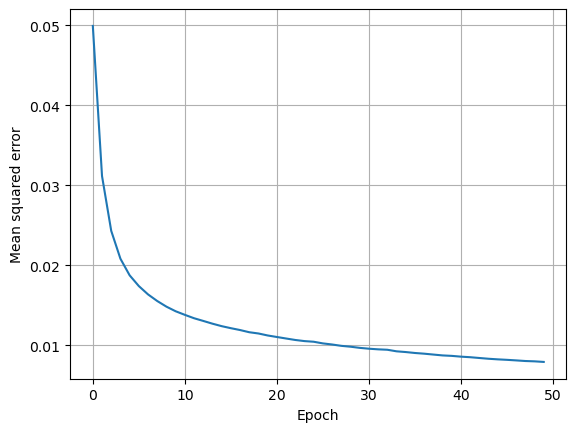

In [17]:
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel('Mean squared error')
plt.xlabel('Epoch')
plt.grid()
plt.show()

Next, let’s take a look at the training and validation accuracy.

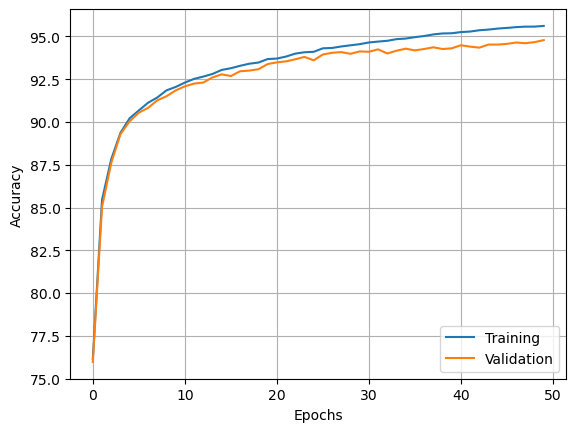

In [18]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc,
         label='Training')
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc,
         label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
plt.grid()
plt.show()

The plot reveals that the gap between training and validation accuracy increases as we train for more
epochs. At approximately the 25th epoch, the training and validation accuracy values are almost equal, 
and then, the network starts to slightly overfit the training data.

Finally, let’s evaluate the generalization performance of the model by calculating the prediction accuracy on the test dataset.

In [19]:
test_mse, test_acc = compute_mse_and_acc(model, X_test, y_test)
print(f'Test accuracy: {test_acc*100:.2f}%')

Test accuracy: 94.54%


Lastly, let’s take a look at some of the images that our MLP struggles with by extracting and plotting 
the first 25 misclassified samples from the test set.

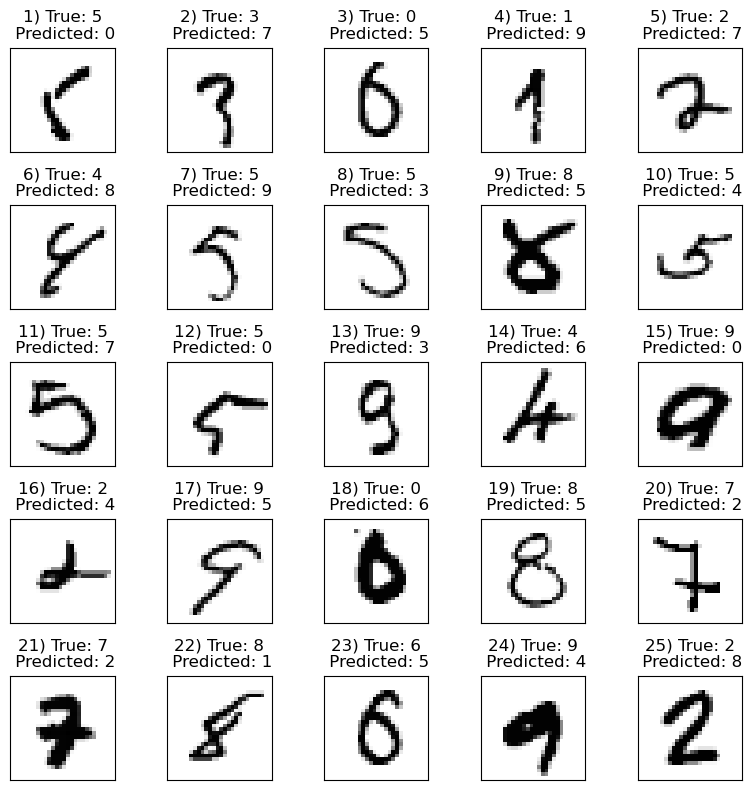

In [20]:
X_test_subset = X_test[:1000, :]
y_test_subset = y_test[:1000]

_, probas = model.forward(X_test_subset)
test_pred = np.argmax(probas, axis=1)

misclassified_images = X_test_subset[y_test_subset != test_pred][:25]
misclassified_labels = test_pred[y_test_subset != test_pred][:25]
correct_labels = y_test_subset[y_test_subset != test_pred][:25]

fig, ax = plt.subplots(nrows=5, ncols=5, 
                       sharex=True, sharey=True, figsize=(8, 8))
ax = ax.flatten()
for i in range(25):
    img = misclassified_images[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')
    ax[i].set_title(f'{i+1}) '
                    f'True: {correct_labels[i]}\n'
                    f' Predicted: {misclassified_labels[i]}')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

The rest of chapter 11 of [1] (p. 360 - 368) is left as reading assignment. 

## 9.2 Building an NN model in PyTorch

PyTorch is one of the most popular deep learning libraries currently available that helps us implement NNs more efficiently. If you have not done so, install PyTorch by executing the cell below.

In [21]:
#!pip install torch torchvision # uncomment this line to install PyTorch

**Note :** See p. 372 of [1] if you have GPU.

Check PyTorch version.

In [22]:
import torch
print('PyTorch version:', torch.__version__)

PyTorch version: 2.8.0+cpu


### 9.2.1 Tensors in PyTorch

#### Creating a tensor

We can simply create a tensor from a list or a NumPy array using the
torch.tensor or the torch.from_numpy function as follows.

In [23]:
a = [1, 2, 3] # a list 
b = np.array([4, 5, 6], dtype=np.int32) # a numpy array of integer
c = np.array([1.2, -3.6, 0.4])  # a numpy array of floating-point values

t_a = torch.tensor(a)
t_b = torch.from_numpy(b)
t_c = torch.from_numpy(c)

print(t_a)
print(t_b)
print(t_c)

tensor([1, 2, 3])
tensor([4, 5, 6], dtype=torch.int32)
tensor([ 1.2000, -3.6000,  0.4000], dtype=torch.float64)


In [24]:
torch.is_tensor(a),torch.is_tensor(b), torch.is_tensor(t_a),torch.is_tensor(t_b)

(False, False, True, True)

We can create a tensor with torch pretty much like using NumPy.

In [25]:
t_ones = torch.ones(2, 3)
print("t_ones shape = "+str(t_ones.shape))
print(t_ones)

t_ones shape = torch.Size([2, 3])
tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [26]:
rand_tensor = torch.rand(2,3)
print(rand_tensor)

tensor([[0.9270, 0.4131, 0.0020],
        [0.9062, 0.0945, 0.6238]])


#### Manipulating the data type and shape of a tensor

The cells below show how to manipulate tensor data types and shapes via several
PyTorch functions that cast, reshape, transpose, and squeeze (remove dimensions).

In [27]:
t_a_new = t_a.to(torch.int64)
print(t_a_new.dtype)

torch.int64


In [28]:
t = torch.rand(3, 5)
t_tr = torch.transpose(t,0,1)
print(t.shape, ' --> ', t_tr.shape)

torch.Size([3, 5])  -->  torch.Size([5, 3])


In [29]:
t = torch.zeros(30)
t_reshape = t.reshape(5, 6)
print(t_reshape.shape)

torch.Size([5, 6])


In [30]:
t = torch.zeros(1, 2, 1, 4, 1)
t_sqz = torch.squeeze(t, 2)
# t_sqz = torch.squeeze(t, 0)
# t_sqz = torch.squeeze(t, 4)
# t_sqz = torch.squeeze(t)
print(t.shape, ' --> ', t_sqz.shape)

torch.Size([1, 2, 1, 4, 1])  -->  torch.Size([1, 2, 4, 1])


#### Applying mathematical operations to tensors 

In this subsection, we will cover some widely used linear algebra
operations, such as element-wise product, matrix multiplication, and computing the norm of a
tensor.

First, let’s instantiate two random tensors, one with uniform distribution in the range [–1, 1) and the
other with a standard normal distribution.

In [31]:
torch.manual_seed(1)

t1 = 2 * torch.rand(5, 2) - 1
t2 = torch.normal(mean=0, std=1, size=(5, 2))

torch.rand returns a tensor filled with random numbers from a uniform distribution in
the range of [0, 1).
Notice that t1 and t2 have the same shape. Now, to compute the element-wise product of t1 and t2,

In [38]:
t1,t2

(tensor([[ 0.5153, -0.4414],
         [-0.1939,  0.4694],
         [-0.9414,  0.5997],
         [-0.2057,  0.5087],
         [ 0.1390, -0.1224]]),
 tensor([[ 0.8590,  0.7056],
         [-0.3406, -1.2720],
         [-1.1948,  0.0250],
         [-0.7627,  1.3969],
         [-0.3245,  0.2879]]))

In [32]:
t3 = torch.multiply(t1, t2)
print(t3)

tensor([[ 0.4426, -0.3114],
        [ 0.0660, -0.5970],
        [ 1.1249,  0.0150],
        [ 0.1569,  0.7107],
        [-0.0451, -0.0352]])


In [33]:
t1

tensor([[ 0.5153, -0.4414],
        [-0.1939,  0.4694],
        [-0.9414,  0.5997],
        [-0.2057,  0.5087],
        [ 0.1390, -0.1224]])

In [34]:
# column-wise 
t4 = torch.mean(t1, axis=0)
# t4 = torch.sum(t1, axis=0)
# t4 = torch.std(t1, axis=0)
print(t4)

tensor([-0.1373,  0.2028])


In [35]:
# can use axis= or dim=
t4a = torch.mean(t1, dim=0)
print(t4a)

tensor([-0.1373,  0.2028])


In [36]:
# row-wise
t4 = torch.mean(t1, axis=1)
# t4 = torch.sum(t1, axis=1)
# t4 = torch.std(t1, axis=1)
print(t4)

tensor([ 0.0369,  0.1378, -0.1709,  0.1515,  0.0083])


The matrix-matrix product between t1 and t2 (that is, $t_1 \times t_2^T$)
can be computed by using the torch.matmul() function.

In [39]:
t1,t2

(tensor([[ 0.5153, -0.4414],
         [-0.1939,  0.4694],
         [-0.9414,  0.5997],
         [-0.2057,  0.5087],
         [ 0.1390, -0.1224]]),
 tensor([[ 0.8590,  0.7056],
         [-0.3406, -1.2720],
         [-1.1948,  0.0250],
         [-0.7627,  1.3969],
         [-0.3245,  0.2879]]))

In [37]:
t5 = torch.matmul(t1, torch.transpose(t2, 0, 1))
print(t5)

tensor([[ 0.1312,  0.3860, -0.6267, -1.0096, -0.2943],
        [ 0.1647, -0.5310,  0.2434,  0.8035,  0.1980],
        [-0.3855, -0.4422,  1.1399,  1.5558,  0.4781],
        [ 0.1822, -0.5771,  0.2585,  0.8676,  0.2132],
        [ 0.0330,  0.1084, -0.1692, -0.2771, -0.0804]])


On the other hand, computing $t_1^T \times t_2$ is performed by transposing t1, resulting in an array of size 2×2

In [40]:
t6 = torch.matmul(torch.transpose(t1, 0, 1), t2)
print(t6)

tensor([[ 1.7453,  0.3392],
        [-1.6038, -0.2180]])


Finally, the torch.linalg.norm() function is useful for computing the $L_p$ norm of a tensor. For example,
we can calculate the $L_2$ norm of t1 as follows

In [41]:
t1

tensor([[ 0.5153, -0.4414],
        [-0.1939,  0.4694],
        [-0.9414,  0.5997],
        [-0.2057,  0.5087],
        [ 0.1390, -0.1224]])

In [42]:
norm_t1 = torch.linalg.norm(t1, ord=2, dim=0)
# norm_t1 = torch.linalg.norm(t1, ord=2, dim=1)
print(norm_t1)

tensor([1.1185, 1.0240])


To verify that this code snippet computes the L2 norm of t1 correctly, you can compare the results with
the following NumPy function

In [43]:
np.sqrt(np.sum(np.square(t1.numpy()), axis=0))
# np.sqrt(np.sum(np.square(t1.numpy()), axis=1))

array([1.1184947, 1.0240096], dtype=float32)

#### Split, stack, and concatenate tensors

In this subsection, we will cover PyTorch operations for splitting a tensor into multiple tensors, or
the reverse: stacking and concatenating multiple tensors into a single one.

Assume that we have a single tensor, and we want to split it into two or more tensors. For this, PyTorch
provides a convenient torch.chunk() function, which divides an input tensor into a list of equally
sized tensors. We can determine the desired number of splits as an integer using the chunks argument
to split a tensor along the desired dimension specified by the dim argument. In this case, the total size
of the input tensor along the specified dimension must be divisible by the desired number of splits.
Alternatively, we can provide the desired sizes in a list using the torch.split() function. Let’s have
a look at an example of both these options:

• Providing the number of splits


In [44]:
torch.manual_seed(1)

t = torch.rand(6)
print(t)

t_splits = torch.chunk(t, 3)
t_splits

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])


(tensor([0.7576, 0.2793]), tensor([0.4031, 0.7347]), tensor([0.0293, 0.7999]))

In [45]:
[item.numpy() for item in t_splits]

[array([0.7576316 , 0.27931088], dtype=float32),
 array([0.40306926, 0.73468447], dtype=float32),
 array([0.02928156, 0.7998586 ], dtype=float32)]

• Providing the sizes of different splits:

Alternatively, instead of defining the number of splits, we can also specify the sizes of the
output tensors directly. Here, we are splitting a tensor of size 5 into tensors of sizes 3 and 2

In [46]:
torch.manual_seed(1)
t = torch.rand(5)
print(t)
t_splits = torch.split(t, split_size_or_sections=[3, 2])
t_splits

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293])


(tensor([0.7576, 0.2793, 0.4031]), tensor([0.7347, 0.0293]))

In [47]:
[item.numpy() for item in t_splits]

[array([0.7576316 , 0.27931088, 0.40306926], dtype=float32),
 array([0.73468447, 0.02928156], dtype=float32)]

Sometimes, we are working with multiple tensors and need to concatenate or stack them to create a
single tensor. In this case, PyTorch functions such as torch.stack() and torch.cat() come in handy.
For example, let’s create a 1D tensor, A, containing 1s with size 3, and a 1D tensor, B, containing 0s
with size 2, and concatenate them into a 1D tensor, C, of size 5

In [48]:
A = torch.ones(3)
B = torch.zeros(2)

C = torch.cat([A, B], axis=0)
print(C)

tensor([1., 1., 1., 0., 0.])


If we create 1D tensors A and B, both with size 3, then we can stack them together to form a 2D
tensor, S

In [49]:
A = torch.ones(3)
B = torch.zeros(3)

S = torch.stack([A, B], axis=1)
print(S)

tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])


In [50]:
S = torch.stack([A, B], axis=0)
print(S)

tensor([[1., 1., 1.],
        [0., 0., 0.]])


Observe differences between torch.cat() and torch.stack() when inputs are matrices.

In [ ]:
A = torch.ones(3,2)
B = torch.zeros(3,2)
C = torch.cat([A, B], axis=0)
print(C)
print(C.shape)
S = torch.stack([A, B], axis=0)
print(S)
print(S.shape)

### 9.2.2 Building input pipelines in PyTorch 

When we are training a deep NN model, we usually train the model incrementally using an iterative
optimization algorithm such as stochastic gradient descent, as we have seen in previous chapters.

torch.nn is a module for building NN models. In cases
where the training dataset is rather small and can be loaded as a tensor into the memory, we can
directly use this tensor for training. In typical use cases, however, when the dataset is too large to fit
into the computer memory, we will need to load the data from the main storage device (for example,
the hard drive or solid-state drive) in chunks, that is, batch by batch. (Note the use of the term “batch”
instead of “mini-batch” in this chapter to stay close to the PyTorch terminology.) In addition, we may
need to construct a data-processing pipeline to apply certain transformations and preprocessing steps
to our data, such as mean centering, scaling, or adding noise to augment the training procedure and
to prevent overfitting.

Applying preprocessing functions manually every time can be quite cumbersome. Luckily, PyTorch
provides a special class for constructing efficient and convenient preprocessing pipelines. In this section,
we will see an overview of different methods for constructing a PyTorch Dataset and DataLoader,
and implementing data loading, shuffling, and batching.

#### Creating a PyTorch DataLoader from existing tensors

If the data already exists in the form of a tensor object, a Python list, or a NumPy array, we can easily
create a dataset loader using the torch.utils.data.DataLoader() class. It returns an object of the
DataLoader class, which we can use to iterate through the individual elements in the input dataset. As
a simple example, consider the following code, which creates a dataset from a list of values from 0 to 5


In [51]:
from torch.utils.data import DataLoader

t = torch.arange(6, dtype=torch.float32)
data_loader = DataLoader(t)

In [52]:
for item in data_loader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


If we want to create batches from this dataset, with a desired batch size of 3, we can do this with the
batch_size argument as follows

In [53]:
data_loader = DataLoader(t, batch_size=3, drop_last=False)

for i, batch in enumerate(data_loader, 1):
    print(f'batch {i}:', batch)

batch 1: tensor([0., 1., 2.])
batch 2: tensor([3., 4., 5.])


This will create two batches from this dataset, where the first three elements go into batch #1, and
the remaining elements go into batch #2. The optional drop_last argument is useful for cases when
the number of elements in the tensor is not divisible by the desired batch size. We can drop the last
non-full batch by setting drop_last to True. The default value for drop_last is False.

We can always iterate through a dataset directly, but as you just saw, DataLoader provides an automatic
and customizable batching to a dataset.

#### Combining two tensors into a joint dataset

Often, we may have the data in two (or possibly more) tensors. For example, we could have a tensor
for features and a tensor for labels. In such cases, we need to build a dataset that combines these
tensors, which will allow us to retrieve the elements of these tensors in tuples.

We first need to create a Dataset class for two tensors : Tensor t_x holds our feature values, and
t_y stores the class labels.

In [54]:
from torch.utils.data import Dataset

class JointDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

A custom Dataset class must contain the following methods to be used by the data loader later on:
.\_\_init\_\_(): This is where the initial logic happens, such as reading existing arrays, loading a
file, filtering data, and so forth.
.\_\_getitem\_\_(): This returns the corresponding sample to the given index.

 For this example, we create these two tensors as follows

In [55]:
torch.manual_seed(1)

t_x = torch.rand([4, 3], dtype=torch.float32)
t_y = torch.arange(4)


Then we create a joint dataset of t_x and t_y with the custom Dataset class

In [56]:
joint_dataset = JointDataset(t_x, t_y)

We can print each example of the joint dataset as follows.

In [57]:
for example in joint_dataset:
    print('  x: ', example[0], 
          '  y: ', example[1])

  x:  tensor([0.7576, 0.2793, 0.4031])   y:  tensor(0)
  x:  tensor([0.7347, 0.0293, 0.7999])   y:  tensor(1)
  x:  tensor([0.3971, 0.7544, 0.5695])   y:  tensor(2)
  x:  tensor([0.4388, 0.6387, 0.5247])   y:  tensor(3)


We can also simply utilize the torch.utils.data.TensorDataset class, if the second dataset is a labeled
dataset in the form of tensors. So, instead of using our self-defined Dataset class, JointDataset, we
can create a joint dataset as follows.

In [58]:
from torch.utils.data import TensorDataset
joint_dataset = TensorDataset(t_x, t_y)

for example in joint_dataset:
    print('  x: ', example[0], 
          '  y: ', example[1])

  x:  tensor([0.7576, 0.2793, 0.4031])   y:  tensor(0)
  x:  tensor([0.7347, 0.0293, 0.7999])   y:  tensor(1)
  x:  tensor([0.3971, 0.7544, 0.5695])   y:  tensor(2)
  x:  tensor([0.4388, 0.6387, 0.5247])   y:  tensor(3)


#### Shuffle, batch, and repeat

When training an NN model using stochastic gradient descent optimization, it is important to feed training
data as randomly shuffled batches. You have already seen how to specify the batch size using the
batch_size argument of a data loader object. Now, in addition to creating batches, you will see how
to shuffle and reiterate over the datasets. We will continue working with the previous joint dataset.

First, let’s create a shuffled version data loader from the joint_dataset dataset

In [61]:
torch.manual_seed(1)
data_loader = DataLoader(dataset=joint_dataset, batch_size=2, shuffle=True)


Here, each batch contains two data records (x) and the corresponding labels (y). Now we iterate through
the data loader entry by entry as follows.

In [62]:
for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0], 
              '\n         y:', batch[1])

batch 1: x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]) 
         y: tensor([2, 0])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])


The rows are shuffled without losing the one-to-one correspondence between the entries in x and y.

In addition, when training a model for multiple epochs, we need to shuffle and iterate over the dataset
by the desired number of epochs. So, let’s iterate over the batched dataset twice.

In [63]:
for epoch in range(2):
    print(f'epoch {epoch+1}')
    for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0], 
              '\n         y:', batch[1])

epoch 1
batch 1: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.3971, 0.7544, 0.5695]]) 
         y: tensor([0, 2])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])
epoch 2
batch 1: x: tensor([[0.4388, 0.6387, 0.5247],
        [0.3971, 0.7544, 0.5695]]) 
         y: tensor([3, 2])
batch 2: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999]]) 
         y: tensor([0, 1])


This results in two different sets of batches. In the first epoch, the first batch contains a pair of values
[y=1, y=2], and the second batch contains a pair of values [y=3, y=0]. In the second epoch, two
batches contain a pair of values, [y=2, y=0] and [y=1, y=3] respectively. For each iteration, the
elements within a batch are also shuffled.

#### Creating a dataset from files on your local storage disk

In this section, we will build a dataset from image files stored on disk. There is an image folder associated
with the online content of this chapter. After downloading the folder, you should be able to see
six images of cats and dogs in JPEG format.

This small dataset will show how building a dataset from stored files generally works. To accomplish
this, we are going to use two additional modules: Image in PIL to read the image file contents and
transforms in torchvision to decode the raw contents and resize the images.

Before we start, let’s take a look at the content of these files. We will use the pathlib library to generate a list of image files 

(You need to copy the files in /cat_dog_images folder from chapter 12 of [1].)

In [64]:
import pathlib

imgdir_path = pathlib.Path('cat_dog_images')

file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')])

print(file_list)

['cat_dog_images\\cat-01.jpg', 'cat_dog_images\\cat-02.jpg', 'cat_dog_images\\cat-03.jpg', 'cat_dog_images\\dog-01.jpg', 'cat_dog_images\\dog-02.jpg', 'cat_dog_images\\dog-03.jpg']


Next, we will visualize these image examples using Matplotlib.

Image shape:  (900, 1200, 3)
Image shape:  (900, 1200, 3)
Image shape:  (900, 742, 3)
Image shape:  (800, 1200, 3)
Image shape:  (800, 1200, 3)
Image shape:  (900, 1200, 3)


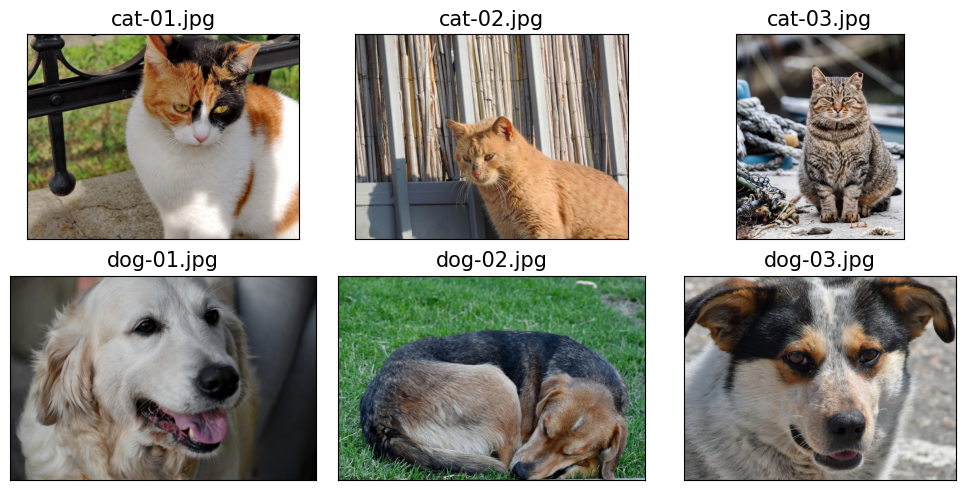

In [65]:
import matplotlib.pyplot as plt
import os
from PIL import Image


fig = plt.figure(figsize=(10, 5))
for i, file in enumerate(file_list):
    img = Image.open(file)
    print('Image shape: ', np.array(img).shape)
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size=15)

plt.tight_layout()
plt.show()

Just from this visualization and the printed image shapes, we can already see that the images have
different aspect ratios. If you print the aspect ratios (or data array shapes) of these images, you will see
that some images are 900 pixels high and 1200 pixels wide (900×1200), some are 800×1200, and one is
900×742. Later, we will preprocess these images to a consistent size. Another point to consider is that
the labels for these images are provided within their filenames. So, we extract these labels from the
list of filenames, assigning label 1 to dogs and label 0 to cats

In [66]:
labels = [1 if 'dog' in os.path.basename(file) else 0
          for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


Now, we have two lists: a list of filenames (or paths of each image) and a list of their labels. In the previous
section, you learned how to create a joint dataset from two arrays. Here, we will do the following

In [67]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels

    def __getitem__(self, index):
        file = self.file_list[index]      
        label = self.labels[index]
        return file, label

    def __len__(self):
        return len(self.labels)
    
image_dataset = ImageDataset(file_list, labels)
for file, label in image_dataset:
    print(file, label)

cat_dog_images\cat-01.jpg 0
cat_dog_images\cat-02.jpg 0
cat_dog_images\cat-03.jpg 0
cat_dog_images\dog-01.jpg 1
cat_dog_images\dog-02.jpg 1
cat_dog_images\dog-03.jpg 1


The joint dataset has filenames and labels.

Next, we need to apply transformations to this dataset: load the image content from its file path, decode
the raw content, and resize it to a desired size, for example, 80×120. As mentioned before, we
use the torchvision.transforms module to resize the images and convert the loaded pixels into
tensors.

In [68]:
import torchvision.transforms as transforms

img_height, img_width = 80, 120
    
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_height, img_width)),
])

Now we update the ImageDataset class with the transform we just defined.

In [ ]:
# from torch.utils.data import Dataset # uncomment this line if you got error.

In [69]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform
    def __getitem__(self, index):
        img = Image.open(self.file_list[index])        
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[index]
        return img, label
    def __len__(self):
        return len(self.labels)


    
image_dataset = ImageDataset(file_list, labels, transform)

Finally, we visualize these transformed image examples using Matplotlib. This results in the following visualization of the retrieved example images, along with their labels.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.000551827..1.0000002].


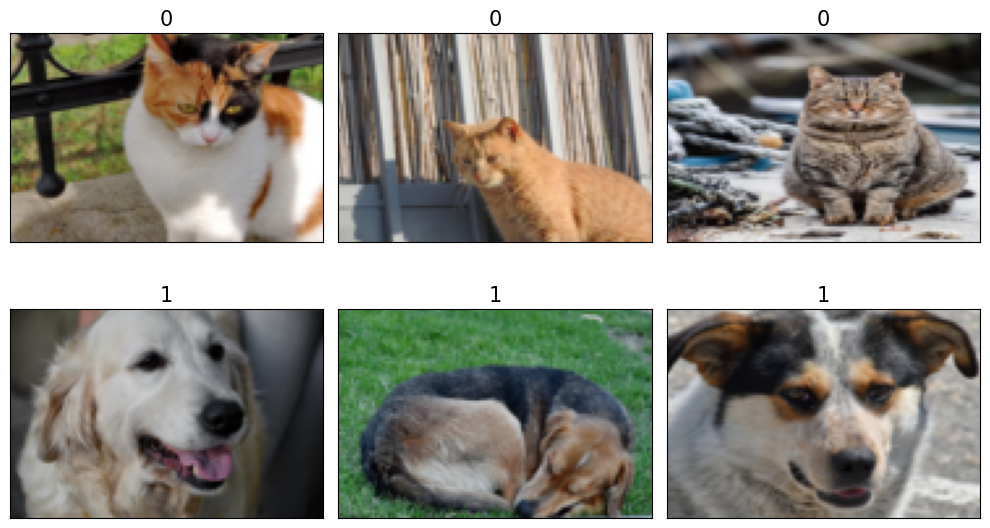

In [70]:
fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(example[0].numpy().transpose((1, 2, 0)))
    ax.set_title(f'{example[1]}', size=15)
    
plt.tight_layout()
plt.show()

The .\_\_getitem__ method in the ImageDataset class wraps all four steps into a single function, including 
the loading of the raw content (images and labels), decoding the images into tensors, and resizing the 
images. The function then returns a dataset that we can iterate over and apply other operations that 
we learned about in the previous sections via a data loader, such as shuffling and batching.

#### Fetching available datasets from the torchvision.datasets library

The torchvision.datasets library provides a nice collection of freely available image datasets for 
training or evaluating deep learning models. Similarly, the torchtext.datasets library provides 
datasets for natural language. Here, we use torchvision.datasets as an example.
The torchvision datasets (https://pytorch.org/vision/stable/datasets.html) are nicely formatted and come with informative descriptions, including the format of features and labels and their type 
and dimensionality, as well as the link to the original source of the dataset. Another advantage is that 
these datasets are all subclasses of torch.utils.data.Dataset, so all the functions we covered in the 
previous sections can be used directly. So, let’s see how to use these datasets in action.

In the following paragraphs, we will cover fetching two different datasets: CelebA (celeb_a) and the 
MNIST digit dataset.

##### CelebA dataset

**Note :** Since the CelebA dataset is large and may take too long to download (depending on the internet speed), this part may be skipped in class.

Let’s first work with the CelebA dataset (http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html) with 
torchvision.datasets.CelebA (https://pytorch.org/vision/stable/datasets.html#celeba). The 
description of torchvision.datasets.CelebA provides some useful information to help us understand 
the structure of this dataset:

* The database has three subsets, 'train', 'valid', and 'test'. We can select a specific subset 
or load all of them with the split parameter.
* The images are stored in PIL.Image format. And we can obtain a transformed version using a 
custom transform function, such as transforms.ToTensor and transforms.Resize.
* There are different types of targets we can use, including 'attributes', 'identity', and 
'landmarks'. 'attributes' is 40 facial attributes for the person in the image, such as facial 
expression, makeup, hair properties, and so on; 'identity' is the person ID for an image; 
and 'landmarks' refers to the dictionary of extracted facial points, such as the position of the 
eyes, nose, and so on.

Next, we will call the torchvision.datasets.CelebA class to download the data, store it on disk in a 
designated folder, and load it into a torch.utils.data.Dataset object

**Note :** You may need to install gdown package before running the cell below.

In [ ]:
#!pip install gdown

In [71]:
import torchvision
image_path = './'
# To save time, change to download=False if you already download the dataset
celeba_dataset = torchvision.datasets.CelebA(image_path, split='train',target_type='attr',download=False)


**Note :** Since this is a large file (1.44G), you may need other methods to avoid error. See [1] for details. 

Now that we have instantiated the datasets, let’s check if the object is of the torch.utils.data.Dataset
class

In [72]:
assert isinstance(celeba_dataset, torch.utils.data.Dataset)

As mentioned, the dataset is already split into train, test, and validation datasets, and we only load the 
train set. And we only use the 'attributes' target. In order to see what the data examples look like, 
we can execute the following code

In [73]:
example = next(iter(celeba_dataset))
print(example)

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218 at 0x2B10ED356D0>, tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]))


Note that the sample in this dataset comes in a tuple of (PIL.Image, attributes). If we want to pass 
this dataset to a supervised deep learning model during training, we have to reformat it as a tuple of 
(features tensor, label). For the label, we will use the 'Smiling' category from the attributes as 
an example, which is the 31st element.

Finally, let’s take the first 18 examples from it to visualize them with their 'Smiling' labels.

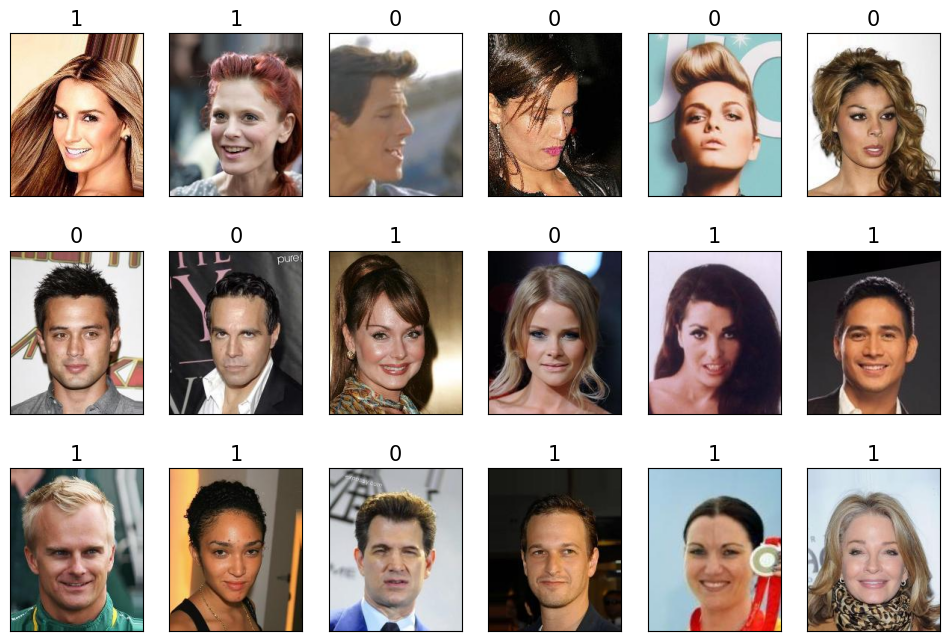

In [74]:
from itertools import islice
fig = plt.figure(figsize=(12, 8))
for i, (image, attributes) in islice(enumerate(celeba_dataset), 18):
    ax = fig.add_subplot(3, 6, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image)
    ax.set_title(f'{attributes[31]}', size=15)
plt.show()

This was all we needed to do to fetch and use the CelebA image dataset.

##### MNIST dataset 

Next, we will proceed with the second dataset from [torchvision.datasets.MNIST](https://pytorch.org/vision/stable/datasets.html#mnist). Let’s see how it can be used to fetch the MNIST digit 
dataset:

* The database has two partitions, 'train' and 'test'. We need to select a specific subset to load.
* The images are stored in PIL.Image format. And we can obtain a transformed version using a 
custom transform function, such as transforms.ToTensor and transforms.Resize.
* There are 10 classes for the target, from 0 to 9.

Now, we can download the 'train' partition, convert the elements to tuples, and visualize 10 examples.

(<PIL.Image.Image image mode=L size=28x28 at 0x2B11763ED50>, 5)


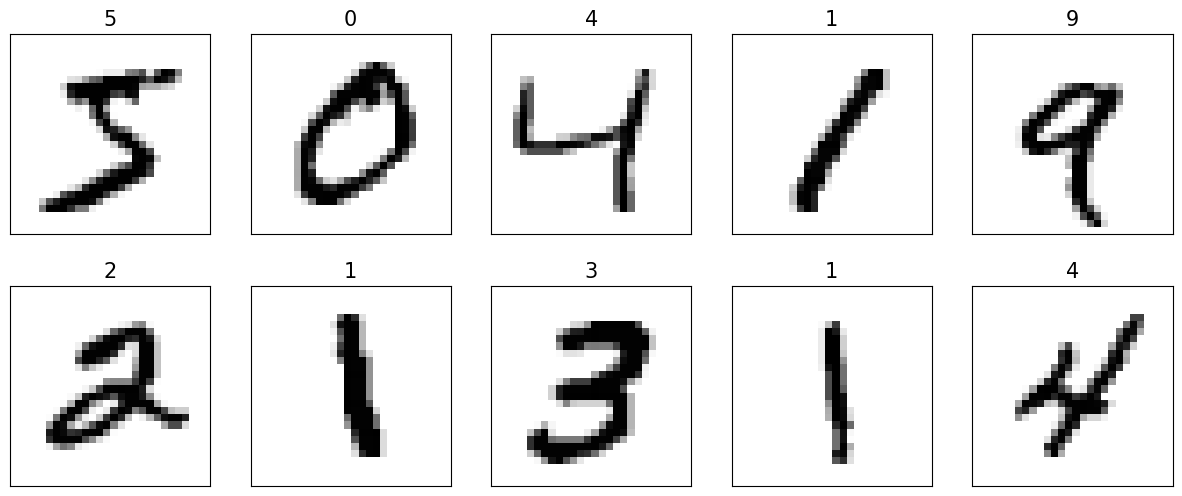

In [75]:
mnist_dataset = torchvision.datasets.MNIST(image_path, 'train', download=False)

assert isinstance(mnist_dataset, torch.utils.data.Dataset)

example = next(iter(mnist_dataset))
print(example)

fig = plt.figure(figsize=(15, 6))
for i, (image, label) in islice(enumerate(mnist_dataset), 10):
    ax = fig.add_subplot(2, 5, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'{label}', size=15)

plt.show()

### 9.2.3 Building an NN model

So far, you have learned about the basic utility components of PyTorch for manipulating tensors and organizing data into formats that we can iterate over during training. In this section, 
we will finally implement our first predictive model in PyTorch. As PyTorch is a bit more flexible but 
also more complex than machine learning libraries such as scikit-learn, we will start with a simple 
linear regression model.

#### The PyTorch neural network module (torch.nn)

torch.nn is an elegantly designed module developed to help create and train NNs. It allows easy prototyping and the building of complex models in just a few lines of code.
To fully utilize the power of the module and customize it for your problem, you need to understand 
what it’s doing. To develop this understanding, we will first train a basic linear regression model on a 
toy dataset without using any features from the torch.nn module; we will use nothing but the basic 
PyTorch tensor operations.
Then, we will incrementally add features from torch.nn and torch.optim. As you will see in the 
following subsections, these modules make building an NN model extremely easy. We will also take 
advantage of the dataset pipeline functionalities supported in PyTorch, such as Dataset and DataLoader, 
which you learned about in the previous section. In this book, we will use the torch.nn module to 
build NN models.
The most commonly used approach for building an NN in PyTorch is through nn.Module, which allows 
layers to be stacked to form a network. This gives us more control over the forward pass. We will see 
examples of building an NN model using the nn.Module class.
Finally, as you will see in the following subsections, a trained model can be saved and reloaded for 
future use.

#### Building a linear regression model

In this subsection, we will build a simple model to solve a linear regression problem. First, let’s create 
a toy dataset in NumPy and visualize it

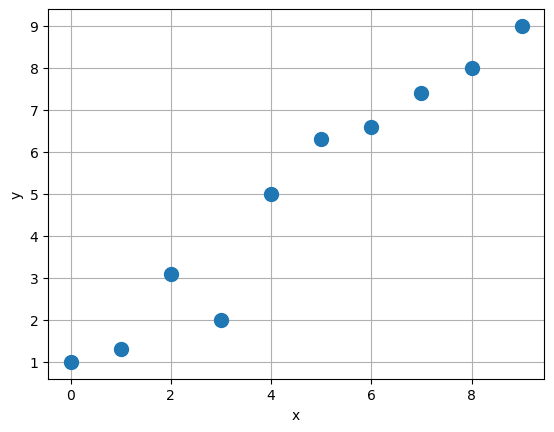

In [76]:
X_train = np.arange(10, dtype='float32').reshape((10, 1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0, 6.3, 6.6, 
                    7.4, 8.0, 9.0], dtype='float32')

plt.plot(X_train, y_train, 'o', markersize=10)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

Next, we will standardize the features (mean centering and dividing by the standard deviation) and 
create a PyTorch Dataset for the training set and a corresponding DataLoader

In [77]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm)

# On some computers the explicit cast to .float() is
# necessary
y_train = torch.from_numpy(y_train).float()

train_ds = TensorDataset(X_train_norm, y_train)

batch_size = 1
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

Here, we set a batch size of 1 for the DataLoader.
    
Now, we can define our model for linear regression as $z = wx + b$. Here, we are going to use the torch.nn
module. It provides predefined layers for building complex NN models, but to start, you will learn how 
to define a model from scratch. Later in this chapter, you will see how to use those predefined layers.

For this regression problem, we will define a linear regression model from scratch. We will define the 
parameters of our model, weight and bias, which correspond to the weight and the bias parameters, 
respectively. Finally, we will define the model() function to determine how this model uses the input 
data to generate its output.

In [78]:
torch.manual_seed(1)
weight = torch.randn(1)
weight.requires_grad_()
bias = torch.zeros(1, requires_grad=True)
 
def model(xb):
    return xb @ weight + bias

After defining the model, we can define the loss function that we want to minimize to find the optimal 
model weights. Here, we will choose the mean squared error (MSE) as our loss function

In [79]:
def loss_fn(input, target):
    return (input-target).pow(2).mean()


Furthermore, to learn the weight parameters of the model, we will use stochastic gradient descent. 
In this subsection, we will implement this training via the stochastic gradient descent procedure 
by ourselves, but in the next subsection, we will use the SGD method from the optimization package, 
torch.optim, to do the same thing.

To implement the stochastic gradient descent algorithm, we need to compute the gradients. Rather 
than manually computing the gradients, we will use PyTorch’s torch.autograd.backward function. 

**Note :** torch.autograd and its different classes and functions for implementing automatic 
differentiation are covered in Chapter 13 of [1], Going Deeper – The Mechanics of PyTorch.

Now, we can set the learning rate and train the model for 200 epochs. The code for training the model 
against the batched version of the dataset is as follows

In [80]:
learning_rate = 0.001
num_epochs = 200
log_epochs = 10

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()

        with torch.no_grad():
            weight -= weight.grad * learning_rate
            bias -= bias.grad * learning_rate
            weight.grad.zero_()
            bias.grad.zero_()
 
    if epoch % log_epochs==0:
        print(f'Epoch {epoch}  Loss {loss.item():.4f}')
 

Epoch 0  Loss 45.0782
Epoch 10  Loss 26.4366
Epoch 20  Loss 1.5918
Epoch 30  Loss 14.1307
Epoch 40  Loss 11.6038
Epoch 50  Loss 6.3084
Epoch 60  Loss 0.6349
Epoch 70  Loss 3.1374
Epoch 80  Loss 1.9999
Epoch 90  Loss 0.3133
Epoch 100  Loss 0.7653
Epoch 110  Loss 1.0039
Epoch 120  Loss 0.0235
Epoch 130  Loss 0.5176
Epoch 140  Loss 0.0759
Epoch 150  Loss 1.8789
Epoch 160  Loss 0.0008
Epoch 170  Loss 0.0866
Epoch 180  Loss 0.0646
Epoch 190  Loss 0.0011


Let’s look at the trained model and plot it. For the test data, we will create a NumPy array of values 
evenly spaced between 0 and 9. Since we trained our model with standardized features, we will also 
apply the same standardization to the test data

Final Parameters: 2.6696107387542725 4.879678249359131


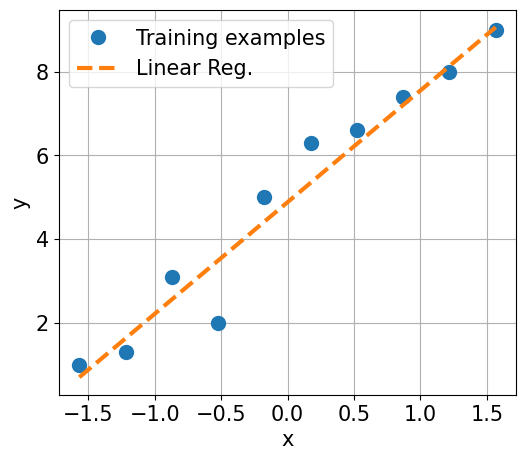

In [81]:
print('Final Parameters:', weight.item(), bias.item())
 
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm).detach().numpy()


fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3)
plt.legend(['Training examples', 'Linear Reg.'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.grid()
plt.show()

#### Model training via the torch.nn and torch.optim modules

In the previous example, we saw how to train a model by writing a custom loss function loss_fn()
and applied stochastic gradient descent optimization. However, writing the loss function and gradient 
updates can be a repeatable task across different projects. The torch.nn module provides a set of loss 
functions, and torch.optim supports most commonly used optimization algorithms that can be called 
to update the parameters based on the computed gradients. To see how they work, let’s create a new 
MSE loss function and a stochastic gradient descent optimizer

In [82]:
import torch.nn as nn

input_size = 1
output_size = 1
model = nn.Linear(input_size, output_size)

loss_fn = nn.MSELoss(reduction='mean')

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Note that here we use the torch.nn.Linear class for the linear layer instead of manually defining it.

Now, we can simply call the step() method of the optimizer to train the model. We can pass a batched 
dataset (such as train_dl, which was created in the previous example)

In [83]:
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        # 1. Generate predictions
        pred = model(x_batch)[:, 0] 

        # 2. Calculate loss
        loss = loss_fn(pred, y_batch)

        # 3. Compute gradients
        loss.backward()

        # 4. Update parameters using gradients
        optimizer.step()

        # 5. Reset the gradients to zero
        optimizer.zero_grad()
        
    if epoch % log_epochs==0:
        print(f'Epoch {epoch}  Loss {loss.item():.4f}')

Epoch 0  Loss 24.6684
Epoch 10  Loss 29.1377
Epoch 20  Loss 20.9207
Epoch 30  Loss 0.1257
Epoch 40  Loss 12.4922
Epoch 50  Loss 1.7845
Epoch 60  Loss 7.6425
Epoch 70  Loss 2.5606
Epoch 80  Loss 0.0157
Epoch 90  Loss 0.7548
Epoch 100  Loss 0.8412
Epoch 110  Loss 0.4923
Epoch 120  Loss 0.0823
Epoch 130  Loss 0.0794
Epoch 140  Loss 0.0891
Epoch 150  Loss 0.0973
Epoch 160  Loss 0.1043
Epoch 170  Loss 0.1103
Epoch 180  Loss 0.0009
Epoch 190  Loss 0.0764


After the model is trained, visualize the results and make sure that they are similar to the results of 
the previous method.

Final Parameters: 2.6496422290802 4.87706995010376


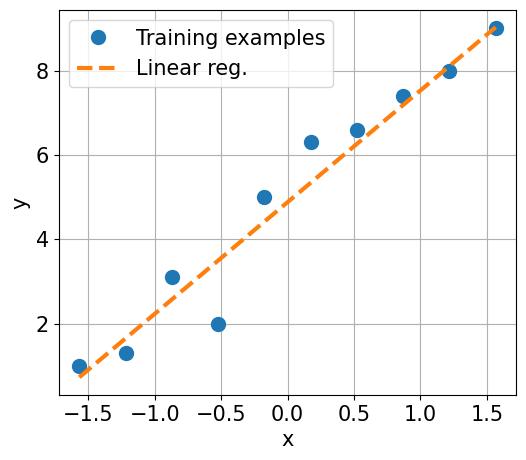

In [84]:
print('Final Parameters:', model.weight.item(), model.bias.item())
 
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm)

fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm.detach().numpy(), y_train.detach().numpy(), 'o', markersize=10)
plt.plot(X_test_norm.detach().numpy(), y_pred.detach().numpy(), '--', lw=3)
plt.legend(['Training examples', 'Linear reg.'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.grid()
plt.show()

#### Building a multilayer perceptron for classifying flowers in the Iris dataset

In the previous example, you saw how to build a model from scratch. We trained this model using 
stochastic gradient descent optimization. While we started our journey based on the simplest possible 
example, you can see that defining the model from scratch, even for such a simple case, is neither 
appealing nor good practice. PyTorch instead provides already defined layers through torch.nn that 
can be readily used as the building blocks of an NN model. In this section, you will learn how to use 
these layers to solve a classification task using the Iris flower dataset (identifying between three species of irises) and build a two-layer perceptron using the torch.nn module. First, let’s get the data 
from sklearn.datasets

In [85]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 

iris = load_iris()
X = iris['data']
y = iris['target']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1./3, random_state=1)

Here, we randomly select 100 samples (2/3) for training and 50 samples (1/3) for testing.
    
Next, we standardize the features (mean centering and dividing by the standard deviation) and create 
a PyTorch Dataset for the training set and a corresponding DataLoader

In [86]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train = torch.from_numpy(y_train) 

train_ds = TensorDataset(X_train_norm, y_train)

torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

Here, we set the batch size to 2 for the DataLoader.
    
Now, we are ready to use the torch.nn module to build a model efficiently. In particular, using the 
nn.Module class, we can stack a few layers and build an NN. You can see the list of all the layers that 
are already available at https://pytorch.org/docs/stable/nn.html. For this problem, we are going 
to use the Linear layer, which is also known as a fully connected layer or dense layer, and can be best 
represented by $f(w \times x + b)$, where x represents a tensor containing the input features, w and b are the 
weight matrix and the bias vector, and f is the activation function.

Each layer in an NN receives its inputs from the preceding layer; therefore, its dimensionality (rank 
and shape) is fixed. Typically, we need to concern ourselves with the dimensionality of output only 
when we design an NN architecture. Here, we want to define a model with two hidden layers. The first 
one receives an input of four features and projects them to 16 neurons. The second layer receives the 
output of the previous layer (which has a size of 16) and projects them to three output neurons, since 
we have three class labels. This can be done as follows

In [87]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)  
        self.layer2 = nn.Linear(hidden_size, output_size)  

    def forward(self, x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        x = nn.Softmax(dim=1)(x)
        return x
    
input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3
 
model = Model(input_size, hidden_size, output_size)



Here, we used the sigmoid activation function for the first layer and softmax activation for the last 
(output) layer. Softmax activation in the last layer is used to support multiclass classification since we 
have three class labels here (which is why we have three neurons in the output layer). We will discuss 
the different activation functions and their applications later in this chapter.

Next, we specify the loss function as cross-entropy loss and the optimizer as Adam

In [88]:
learning_rate = 0.001

loss_fn = nn.CrossEntropyLoss()
 
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


Now, we can train the model. We will specify the number of epochs to be 100. The code of training 
the flower classification model is as follows

In [89]:
num_epochs = 100
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs

for epoch in range(num_epochs):

    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch.long())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    
        loss_hist[epoch] += loss.item()*y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_hist[epoch] += is_correct.sum()
        
    loss_hist[epoch] /= len(train_dl.dataset)
    accuracy_hist[epoch] /= len(train_dl.dataset)

The loss_hist and accuracy_hist lists keep the training loss and the training accuracy after each 
epoch. We can use this to visualize the learning curves as follows

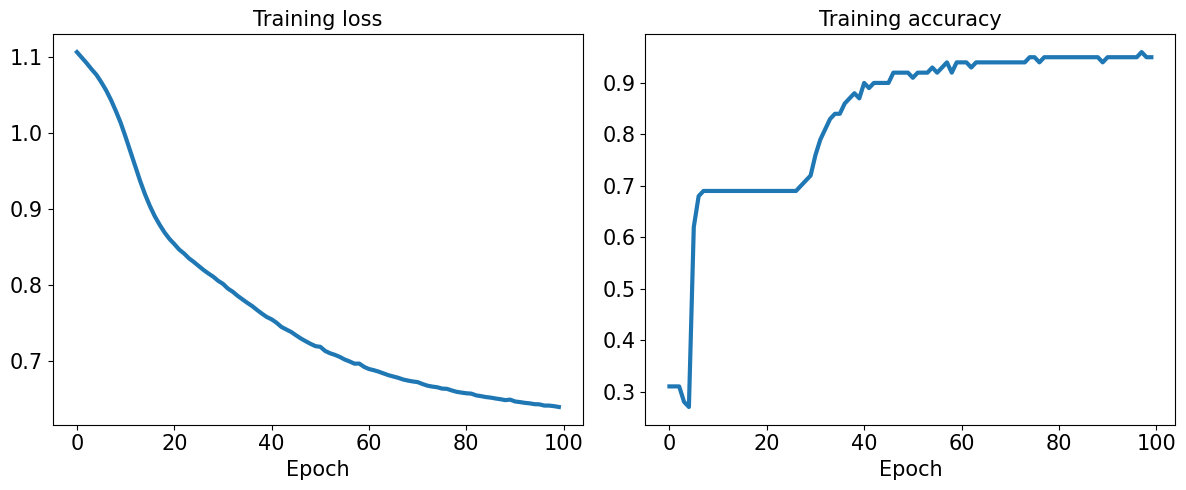

In [90]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout()
 
plt.show()

#### Evaluating the trained model on the test dataset

We can now evaluate the classification accuracy of the trained model on the test dataset

In [91]:
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm).float()
y_test = torch.from_numpy(y_test) 
pred_test = model(X_test_norm)

correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
 
print(f'Test Acc.: {accuracy:.4f}')


Test Acc.: 0.9800


Since we trained our model with standardized features, we also applied the same standardization to 
the test data. The classification accuracy is 0.98 (that is, 98 percent).

#### Saving and reloading the trained model

Trained models can be saved on disk for future use. This can be done as follows

In [92]:
path = 'iris_classifier.pt'
torch.save(model, path)

Calling save(model) will save both the model architecture and all the learned parameters. As a common convention, we can save models using a 'pt' or 'pth' file extension.

Now, let’s reload the saved model. Since we have saved both the model architecture and the weights, 
we can easily rebuild and reload the parameters in just one line. Verify the model architecture by calling model_new.eval()

In [93]:
model_new = torch.load(path,weights_only=False) # for new version of PyTorch, weights_only is default to True
model_new.eval()

Model(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)

Finally, let’s evaluate this new model that is reloaded on the test dataset to verify that the results are 
the same as before

In [94]:
pred_test = model_new(X_test_norm)

correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
 
print(f'Test Acc.: {accuracy:.4f}')

Test Acc.: 0.9800


If you want to save only the learned parameters, you can use save(model.state_dict())

In [95]:
path = 'iris_classifier_state.pt'
torch.save(model.state_dict(), path)

To reload the saved parameters, we first need to construct the model as we did before, then feed the 
loaded parameters to the model


In [96]:
model_new = Model(input_size, hidden_size, output_size)
model_new.load_state_dict(torch.load(path))

pred_test = model_new(X_test_norm)

correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
 
print(f'Test Acc.: {accuracy:.4f}')

Test Acc.: 0.9800


### 9.2.4 Choosing activation functions for multilayer neural networks

For simplicity, we have only discussed the sigmoid activation function in the context of multilayer 
feedforward NNs so far; we have used it in the hidden layer as well as the output layer in the MLP 
implementation in Section 9.1.

Note that in this book, the sigmoidal logistic function, $\sigma(z) = \frac{1}{1+e^{-z}}$ is referred to as the sigmoid function 
for brevity, which is common in machine learning literature. In the following subsections, you will 
learn more about alternative nonlinear functions that are useful for implementing multilayer NNs.

Technically, we can use any function as an activation function in multilayer NNs as long as it is differentiable.
We can even use linear activation functions, such as in Adaline. However, in practice, it would not be very useful to use 
linear activation functions for both hidden and output layers, since we want to introduce nonlinearity 
in a typical artificial NN to be able to tackle complex problems. The sum of linear functions yields a 
linear function after all.

The logistic (sigmoid) activation function probably mimics the concept of a 
neuron in a brain most closely—we can think of it as the probability of whether a neuron fires. However, 
the logistic (sigmoid) activation function can be problematic if we have highly negative input, since 
the output of the sigmoid function will be close to zero in this case. If the sigmoid function returns 
output that is close to zero, the NN will learn very slowly, and it will be more likely to get trapped in 
the local minima of the loss landscape during training. This is why people often prefer a hyperbolic 
tangent as an activation function in hidden layers.

Before we discuss what a hyperbolic tangent looks like, let’s briefly recapitulate some of the basics of 
the logistic function and look at a generalization that makes it more useful for multiclass classification 
problems.

#### Logistic function recap

As was mentioned in the introduction to this section, the logistic function is, in fact, a special case of a 
sigmoid function. You will recall from the section on logistic regression in Chapter 3 of [1] that we can use 
a logistic function to model the probability that 
sample $x$ belongs to the positive class (class 1) in a binary classification task.
The given net input, $z$, is shown in the following equation:
$$
z = w_0x_0 + w_1x_1  + \ldots + w_mx_m = \sum_{i=0}^m x_ix_i = w^Tx \tag{9.11}
$$
The logistic (sigmoid) function will compute the following
$$
\sigma_{logistic}(z) = \frac{1}{1+e^{-z}} \tag{9.12}
$$
Note that $w_0$ is the bias unit (y-axis intercept, which means $x_0 = 1$). To provide a more concrete example, 
let’s take a model for a two-dimensional data point, $x$, and a model with the following weight 
coefficients assigned to the $w$ vector

In [97]:
import numpy as np

X = np.array([1, 1.4, 2.5]) ## first value must be 1
w = np.array([0.4, 0.3, 0.5])

def net_input(X, w):
    return np.dot(X, w)

def logistic(z):
    return 1.0 / (1.0 + np.exp(-z))

def logistic_activation(X, w):
    z = net_input(X, w)
    return logistic(z)

print(f'P(y=1|x) = {logistic_activation(X, w):.3f}') 

P(y=1|x) = 0.888


If we calculate the net input $(z)$ and use it to activate a logistic neuron with those particular feature 
values and weight coefficients, we get a value of 0.888, which we can interpret as an 88.8 percent 
probability that this particular sample, x, belongs to the positive class.
    
In Section 9.1, we used the one-hot encoding technique to represent multiclass ground truth labels and 
designed the output layer consisting of multiple logistic activation units. However, as will be demonstrated by the following code example, an output layer consisting of multiple logistic activation units 
does not produce meaningful, interpretable probability values

In [98]:
# W : array with shape = (n_output_units, n_hidden_units+1)
# note that the first column are the bias units

W = np.array([[1.1, 1.2, 0.8, 0.4],
              [0.2, 0.4, 1.0, 0.2],
              [0.6, 1.5, 1.2, 0.7]])

# A : data array with shape = (n_hidden_units + 1, n_samples)
# note that the first column of this array must be 1

A = np.array([[1, 0.1, 0.4, 0.6]])
Z = np.dot(W, A[0])
y_probas = logistic(Z)
print('Net Input: \n', Z)

print('Output Units:\n', y_probas) 

Net Input: 
 [1.78 0.76 1.65]
Output Units:
 [0.85569687 0.68135373 0.83889105]


As you can see in the output, the resulting values cannot be interpreted as probabilities for a three-class 
problem. The reason for this is that they do not sum to 1. However, this is, in fact, not a big concern 
if we use our model to predict only the class labels and not the class membership probabilities. One 
way to predict the class label from the output units obtained earlier is to use the maximum value

In [99]:
y_class = np.argmax(Z, axis=0)
print('Predicted class label:', y_class) 

Predicted class label: 0


In certain contexts, it can be useful to compute meaningful class probabilities for multiclass predictions. In the next section, we will take a look at a generalization of the logistic function, the softmax
function, which can help us with this task.

#### Estimating class probabilities in multiclass classification via the softmax function

In the previous section, you saw how we can obtain a class label using the argmax function. Previously, 
in the Building a multilayer perceptron for classifying flowers in the Iris dataset section, we determined 
activation='softmax' in the last layer of the MLP model. The softmax function is a soft form of 
the argmax function; instead of giving a single class index, it provides the probability of each class. 
Therefore, it allows us to compute meaningful class probabilities in multiclass settings (multinomial 
logistic regression).

In softmax, the probability of a particular sample with net input $z$ belonging to the ith class can be 
computed with a normalization term in the denominator, that is, the sum of the exponentially weighted 
linear functions
$$
p(z) = \sigma(z) = \frac{e^{z_i}}{\sum_{j=1}^Me^{z_j}} \tag{9.13}
$$
We can create a Python function of (9.13) as follows:

In [100]:
def softmax(z):
    return np.exp(z) / np.sum(np.exp(z))

y_probas = softmax(Z)
print('Probabilities:\n', y_probas)

np.sum(y_probas)

Probabilities:
 [0.44668973 0.16107406 0.39223621]


np.float64(1.0)

As you can see, the predicted class probabilities now sum to 1, as we would expect. It is also notable 
that the predicted class label is the same as when we applied the argmax function to the logistic output.

It may help to think of the result of the softmax function as a normalized output that is useful for obtaining meaningful class-membership predictions in multiclass settings. Therefore, when we build a 
multiclass classification model in PyTorch, we can use the torch.softmax() function to estimate the 
probabilities of each class membership for an input batch of examples. To see how we can use the 
torch.softmax() activation function in PyTorch, we will convert Z to a tensor in the following code, 
with an additional dimension reserved for the batch size

In [101]:
torch.softmax(torch.from_numpy(Z), dim=0)

tensor([0.4467, 0.1611, 0.3922], dtype=torch.float64)

#### Broadening the output spectrum using a hyperbolic tangent

Another sigmoidal function that is often used in the hidden layers of artificial NNs is the **hyperbolic 
tangent** (commonly known as **tanh**), which can be interpreted as a rescaled version of the logistic 
function $\sigma_{logistic}(z) = \frac{1}{1+e^{-z}}$
$$
\sigma_{tanh}(z) = 2 \times \sigma_{logistic}(2z) -1 = \frac{e^z - e^{-z}}{e^z+e^{-z}} \tag{9.14}
$$
The advantage of the hyperbolic tangent over the logistic function is that it has a broader output 
spectrum ranging in the open interval (–1, 1), which can improve the convergence of the backpropagation algorithm [5].

In contrast, the logistic function returns an output signal ranging in the open interval (0, 1). For a simple 
comparison of the logistic function and the hyperbolic tangent, let’s plot the two sigmoidal functions

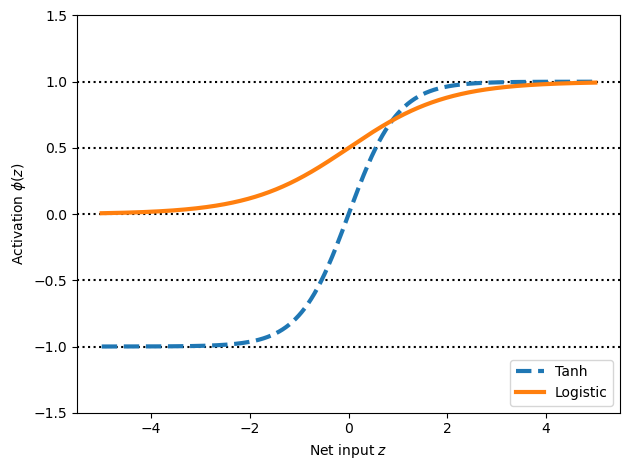

In [102]:
def tanh(z):
    e_p = np.exp(z)
    e_m = np.exp(-z)
    return (e_p - e_m) / (e_p + e_m)

z = np.arange(-5, 5, 0.005)
log_act = logistic(z)
tanh_act = tanh(z)
plt.ylim([-1.5, 1.5])
plt.xlabel('Net input $z$')
plt.ylabel('Activation $\\phi(z)$')
plt.axhline(1, color='black', linestyle=':')
plt.axhline(0.5, color='black', linestyle=':')
plt.axhline(0, color='black', linestyle=':')
plt.axhline(-0.5, color='black', linestyle=':')
plt.axhline(-1, color='black', linestyle=':')
plt.plot(z, tanh_act,
    linewidth=3, linestyle='--',
    label='Tanh')
plt.plot(z, log_act,
    linewidth=3,
    label='Logistic')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In practice, we can use NumPy’s tanh function.
Alternatively, when building an NN model, we can use torch.tanh(x) in PyTorch to achieve the same 
results

In [103]:
np.tanh(z)

array([-0.9999092 , -0.99990829, -0.99990737, ...,  0.99990644,
        0.99990737,  0.99990829], shape=(2000,))

In [104]:
torch.tanh(torch.from_numpy(z))

tensor([-0.9999, -0.9999, -0.9999,  ...,  0.9999,  0.9999,  0.9999],
       dtype=torch.float64)

#### Rectified linear unit activation

The rectified linear unit (ReLU) is another activation function that is often used in deep NNs. Before 
we delve into ReLU, we should step back and understand the vanishing gradient problem of tanh and 
logistic activations.

To understand this problem, let’s assume that we initially have the net input $z_1 = 20$, which changes to 
$z_2 = 25$. Computing the tanh activation, we get $\sigma(z_1) = 1.0$ and $\sigma(z_2) = 1.0$, which shows no change in 
the output (due to the asymptotic behavior of the tanh function and numerical errors).

This means that the derivative of activations with respect to the net input diminishes as $z$ becomes 
large. As a result, learning the weights during the training phase becomes very slow because the gradient 
terms may be very close to zero. ReLU activation addresses this issue. Mathematically, ReLU is 
defined as 
$$
\sigma_{ReLU}(z) = max(0,z) \tag{9.15}
$$

ReLU is still a nonlinear function that is good for learning complex functions with NNs. Besides this, 
the derivative of ReLU, with respect to its input, is always 1 for positive input values. Therefore, it 
solves the problem of vanishing gradients, making it suitable for deep NNs. In PyTorch, we can apply 
the ReLU activation torch.relu() as follows

In [105]:
relu = torch.relu(torch.from_numpy(z))
relu

tensor([0.0000, 0.0000, 0.0000,  ..., 4.9850, 4.9900, 4.9950],
       dtype=torch.float64)

To see the graph of ReLU 

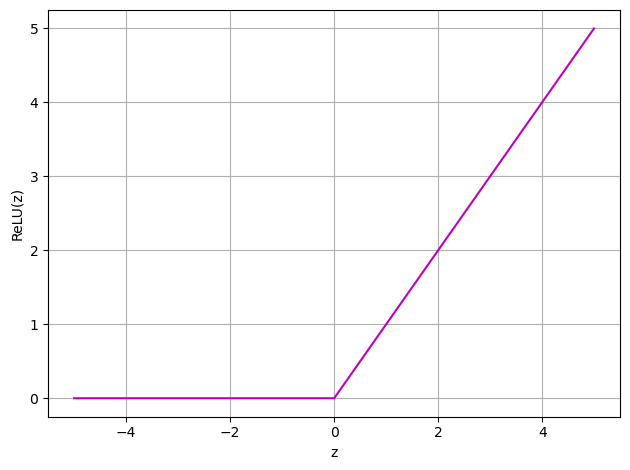

In [106]:
plt.plot(z,relu,'m-')
plt.xlabel('z')
plt.ylabel('ReLU(z)')
plt.grid()
plt.tight_layout()
plt.show()

We will use the ReLU activation function in the next lecture as an activation function for multilayer 
convolutional NNs.

Let's conclude this section with an overview of the different activation functions that we have 
encountered so far

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch12/figures/12_11.png" width=800 />

Figure 9.5  Activation function list (Figure 12.11 of [1])

## 9.3 The Mechanics of PyTorch

Chapter 13 of [1] is left as reading assignment. You should try the notebook from the book's github. 


### Related Videos

#### Lectures from top universities
<ul>
<li />CS229-2022 : <a href="https://youtu.be/ZMxfDWPXmjc?si=_qlmYqjifIwgXnun">Lecture 8 : Neural Networks 1</a> <a href="https://youtu.be/UbtTv7j1tzU?si=SkZvwgq19cguYTgQ">Lecture 9 : Neural Networks 2 </a>
<li />MIT Machine learning 6.036 (Fall 2020) : <a href="https://youtu.be/N0uGnAfXUes?si=eZkgG4VhzpGE0a1O">Lecture 6 : Neural Networks</a>
<li />University of Tübingen Machine Learning I (2020/21) : <a href="https://youtu.be/Uf9xJDJt1KA?si=N_EAwkmOGKdfXHwL">07 - Neural networks and deep learning</a>
<li />Sebastian Raschka, <a href="https://youtube.com/playlist?list=PLTKMiZHVd_2KJtIXOW0zFhFfBaJJilH51&si=gvo9FQky-jsbBlm-">Intro to Deep Learning and Generative Model playlist</a> 
</ul>

#### General 
<ul>
<li /><a href="https://youtube.com/playlist?list=PLkDaE6sCZn6Ec-XTbcX1uRg2_u4xOEky0&si=RHDJPVKjvilc-b-1">Deep Learning Specialization (C1W1L01)</a> by Andrew NG
<li /><a href="https://youtu.be/V_xro1bcAuA?si=qI4Hg2DawhorNOLr">PyTorch for Deep Learning & Machine Learning – Full Course</a> by Daniel Bourke


</ul>



### References

1. S. Raschka, Y. Liu and V. Mirjalili. [Machine Learning with PyTorch 
and Scikit-Learn.](https://sebastianraschka.com/blog/2022/ml-pytorch-book.html) Packt Publishing. 2022.  

2. A. Ng and T. Ma. [CS229 Lecture Notes.](https://cs229.stanford.edu/main_notes.pdf) Stanford University. 2023.

3. F. Chollet. Deep Learning with Python 2ed. Manning Publications Co. 2021.

4. Y. LeCun, L. Bottou, Y. Bengio, and P. Haffner. Gradient-Based Learning Applied to Document Recognition , Proceedings of the IEEE, 86(11): 2278-2324, 1998.

5. C.M. Bishop. Neural Networks for Pattern Recognition, Oxford University Press, 1995.



<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2025</div>